# Additional Models
1. Try Decision Tree and Random Forest regressors. 
2. Compare their test R² against baseline. 
3. Document model behavior (strengths/weaknesses)

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')

Y_train = np.load('Y_train.npy')
Y_val = np.load('Y_val.npy')
Y_test = np.load('Y_test.npy')

# convert Y 2D arrays to 1D arrays
Y_train = pd.DataFrame(Y_train)[0].values
Y_val = pd.DataFrame(Y_val)[0].values
Y_test = pd.DataFrame(Y_test)[0].values

### 1a. Decision Tree

Create two versions of X_train and Y_train where one has outliers removed.

In [242]:
combined_df = pd.concat([X_train, pd.DataFrame(Y_train)], axis=1).rename(columns={0: 'ClosePrice'})

Q1 = np.log1p(combined_df['ClosePrice']).quantile(0.25)
Q3 = np.log1p(combined_df['ClosePrice']).quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

is_outlier = (np.log1p(combined_df['ClosePrice']) <= lower_bound) | (np.log1p(combined_df['ClosePrice']) >= upper_bound)

combined_df = combined_df[~is_outlier]

X_train_no_outliers = combined_df.drop(['ClosePrice'], axis=1)
Y_train_no_outliers = combined_df[['ClosePrice']]

In [243]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# scores are on the log scale

# training before removing outliers

dt1 = DecisionTreeRegressor(max_depth=8, random_state=42)
dt1.fit(X_train, np.log1p(Y_train))

pred_val_dt1 = dt1.predict(X_val)

print("---Outliers included in training---")
print("Decision Tree R²:", r2_score(np.log1p(Y_val), pred_val_dt1))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(np.log1p(Y_val), pred_val_dt1)))
print("Decision Tree MAE:", mean_absolute_error(np.log1p(Y_val), pred_val_dt1))

print()

# training after removing outliers

dt2 = DecisionTreeRegressor(max_depth=8, random_state=42)
dt2.fit(X_train_no_outliers, np.log1p(Y_train_no_outliers))

pred_val_dt2 = dt2.predict(X_val)

print("---Outliers excluded in training---")
print("Decision Tree R²:", r2_score(np.log1p(Y_val), pred_val_dt2))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(np.log1p(Y_val), pred_val_dt2)))
print("Decision Tree MAE:", mean_absolute_error(np.log1p(Y_val), pred_val_dt2))

---Outliers included in training---
Decision Tree R²: 0.8439310892058624
Decision Tree RMSE: 0.27223810093856426
Decision Tree MAE: 0.17932234572323136

---Outliers excluded in training---
Decision Tree R²: 0.8171645146072348
Decision Tree RMSE: 0.2946598418286103
Decision Tree MAE: 0.1847047218340386


In [244]:
# scores on the dollar scale

# training before removing outliers

dt1 = DecisionTreeRegressor(max_depth=8, random_state=42)
dt1.fit(X_train, np.log1p(Y_train))

pred_val_dt1_dollar = np.expm1(dt1.predict(X_val))

print("---Outliers included in training---")
print("Decision Tree R²:", r2_score(Y_val, pred_val_dt1_dollar))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(Y_val, pred_val_dt1_dollar)))
print("Decision Tree MAE:", mean_absolute_error(Y_val, pred_val_dt1_dollar))

print()

# training after removing outliers

dt2 = DecisionTreeRegressor(max_depth=8, random_state=42)
dt2.fit(X_train_no_outliers, np.log1p(Y_train_no_outliers))

pred_val_dt2_dollar = np.expm1(dt2.predict(X_val))

print("---Outliers excluded in training---")
print("Decision Tree R²:", r2_score(Y_val, pred_val_dt2_dollar))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(Y_val, pred_val_dt2_dollar)))
print("Decision Tree MAE:", mean_absolute_error(Y_val, pred_val_dt2_dollar))

---Outliers included in training---
Decision Tree R²: 0.015000954141310308
Decision Tree RMSE: 9657298.391833888
Decision Tree MAE: 404192.55698051513

---Outliers excluded in training---
Decision Tree R²: 0.00875756724806065
Decision Tree RMSE: 9687856.293761805
Decision Tree MAE: 435967.2364006928


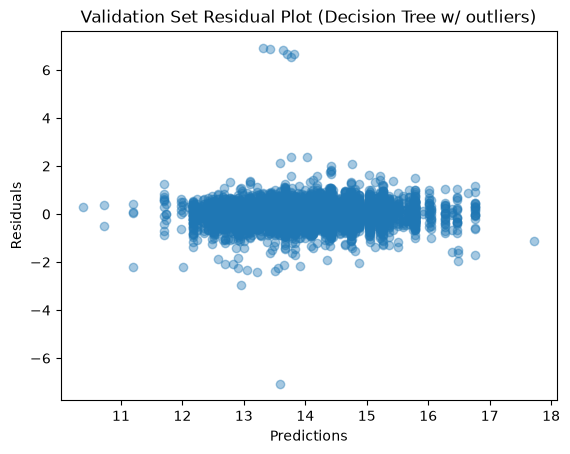

In [245]:
residuals_dt1 = np.log1p(Y_val) - pred_val_dt1

plt.scatter(pred_val_dt1, residuals_dt1, alpha=0.4)
plt.title('Validation Set Residual Plot (Decision Tree w/ outliers)')
plt.xlabel('Predictions')
plt.ylabel('Residuals');

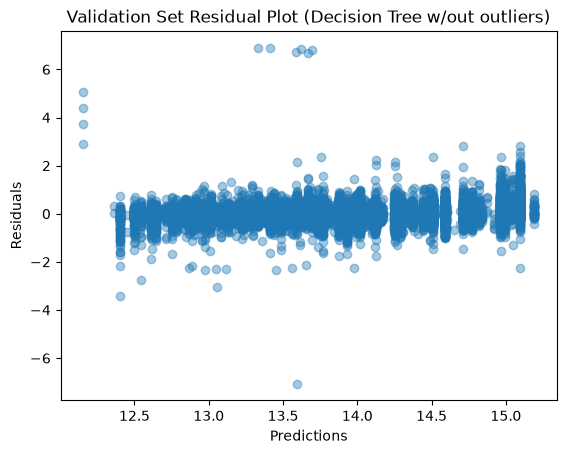

In [246]:
residuals_dt2 = np.log1p(Y_val) - pred_val_dt2

plt.scatter(pred_val_dt2, residuals_dt2, alpha=0.4)
plt.title('Validation Set Residual Plot (Decision Tree w/out outliers)')
plt.xlabel('Predictions')
plt.ylabel('Residuals');

In [247]:
X_val[residuals_dt1 > 4]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
1583,33.022839,-116.804242,3.337237e+06,3.337237e+06,3.337237e+06,4.310591e+06,7.656810,3.0,2.0,1984.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5247,33.675959,-117.290553,6.086742e+05,6.460582e+05,6.565944e+05,6.654474e+05,7.633370,4.0,3.0,1997.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17017,32.625679,-117.065524,2.246132e+06,8.330027e+05,8.330027e+05,2.801790e+06,7.597396,4.0,3.0,1959.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26394,33.185572,-117.302394,9.903902e+05,9.348892e+05,9.366149e+05,9.389217e+05,7.007601,2.0,1.0,1972.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29606,32.572879,-117.062559,1.780421e+06,3.813746e+06,3.834100e+06,2.801790e+06,7.275865,4.0,2.0,1978.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30036,33.250628,-117.135871,1.034057e+06,1.035868e+06,1.034057e+06,1.021090e+06,7.568896,2.0,3.0,1977.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [248]:
X_val[residuals_dt2 > 6]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
1583,33.022839,-116.804242,3.337237e+06,3.337237e+06,3.337237e+06,4.310591e+06,7.656810,3.0,2.0,1984.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5247,33.675959,-117.290553,6.086742e+05,6.460582e+05,6.565944e+05,6.654474e+05,7.633370,4.0,3.0,1997.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17017,32.625679,-117.065524,2.246132e+06,8.330027e+05,8.330027e+05,2.801790e+06,7.597396,4.0,3.0,1959.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26394,33.185572,-117.302394,9.903902e+05,9.348892e+05,9.366149e+05,9.389217e+05,7.007601,2.0,1.0,1972.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29606,32.572879,-117.062559,1.780421e+06,3.813746e+06,3.834100e+06,2.801790e+06,7.275865,4.0,2.0,1978.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30036,33.250628,-117.135871,1.034057e+06,1.035868e+06,1.034057e+06,1.021090e+06,7.568896,2.0,3.0,1977.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [249]:
pd.DataFrame(Y_val).sort_values(0, ascending=False).head(6)

,0
30036,796000000.0
29606,768500000.0
1583,699000000.0
17017,664250000.0
26394,645000000.0
5247,615000000.0


In [250]:
X_val[residuals_dt1 < -6]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
28982,37.978534,-121.70934,699317.001873,706234.055416,1.337450e+06,1.551243e+06,8.000014,5.0,4.0,2026.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [251]:
X_val[residuals_dt2 < -6]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
28982,37.978534,-121.70934,699317.001873,706234.055416,1.337450e+06,1.551243e+06,8.000014,5.0,4.0,2026.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [252]:
pd.DataFrame(Y_val).sort_values(0).head(1)

,0
28982,685.0


Our model underestimates high-valued properties. This is occuring for the 6 most expensive properties in our validation set. The model overvalues the lowest-valued property in our dataset as well.

### 1b. Random Forest

In [253]:
from sklearn.ensemble import RandomForestRegressor

# Before removing outliers

rf1 = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=10, max_features=0.3, n_jobs=-1, random_state=42)
rf1.fit(X_train, np.log1p(Y_train))

pred_val_rf1 = rf1.predict(X_val)

print("---Outliers included in training---")
print("Random Forest R²:", r2_score(np.log1p(Y_val), pred_val_rf1))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(np.log1p(Y_val), pred_val_rf1)))
print("Random Forest MAE:", mean_absolute_error(np.log1p(Y_val), pred_val_rf1))

print()

# After removing outliers

rf2 = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=10, max_features=0.3, n_jobs=-1, random_state=42)
rf2.fit(X_train_no_outliers, np.log1p(Y_train_no_outliers))

pred_val_rf2 = rf2.predict(X_val)

print("---Outliers excluded in training---")
print("Random Forest R²:", r2_score(np.log1p(Y_val), pred_val_rf2))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(np.log1p(Y_val), pred_val_rf2)))
print("Random Forest MAE:", mean_absolute_error(np.log1p(Y_val), pred_val_rf2))

---Outliers included in training---
Random Forest R²: 0.8847374973112934
Random Forest RMSE: 0.2339562919305777
Random Forest MAE: 0.14379697316036374



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


---Outliers excluded in training---
Random Forest R²: 0.8604008955623845
Random Forest RMSE: 0.25747319542422803
Random Forest MAE: 0.15151439987558687


In [254]:
# on dollar scale

# Before removing outliers

rf1 = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=10, max_features=0.3, n_jobs=-1, random_state=42)
rf1.fit(X_train, np.log1p(Y_train))

pred_val_rf1_dollar = np.expm1(rf1.predict(X_val))

print("---Outliers included in training---")
print("Random Forest R²:", r2_score(Y_val, pred_val_rf1_dollar))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(Y_val, pred_val_rf1_dollar)))
print("Random Forest MAE:", mean_absolute_error(Y_val, pred_val_rf1_dollar))

print()

# After removing outliers

rf2 = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=10, max_features=0.3, n_jobs=-1, random_state=42)
rf2.fit(X_train_no_outliers, np.log1p(Y_train_no_outliers))

pred_val_rf2_dollar = rf2.predict(X_val)

print("---Outliers excluded in training---")
print("Random Forest R²:", r2_score(Y_val, pred_val_rf2_dollar))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(Y_val, pred_val_rf2_dollar)))
print("Random Forest MAE:", mean_absolute_error(Y_val, pred_val_rf2_dollar))

---Outliers included in training---
Random Forest R²: 0.015374110231624383
Random Forest RMSE: 9655468.937737284
Random Forest MAE: 385967.9374447878



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


---Outliers excluded in training---
Random Forest R²: -0.021091985395575552
Random Forest RMSE: 9832640.917678356
Random Forest MAE: 1413177.0806076315


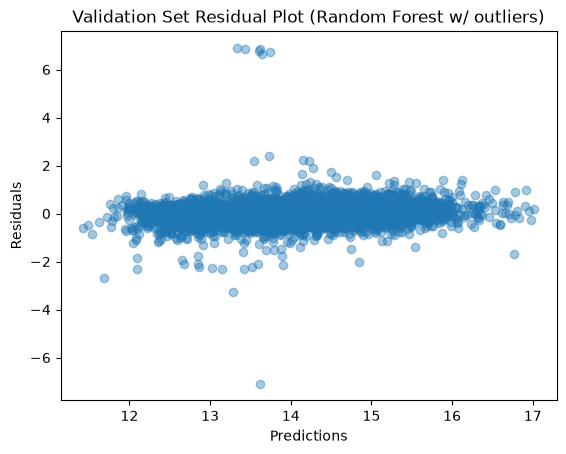

In [255]:
residuals_rf1 = np.log1p(Y_val) - pred_val_rf1

plt.scatter(pred_val_rf1, residuals_rf1, alpha=0.4)
plt.title('Validation Set Residual Plot (Random Forest w/ outliers)')
plt.xlabel('Predictions')
plt.ylabel('Residuals');

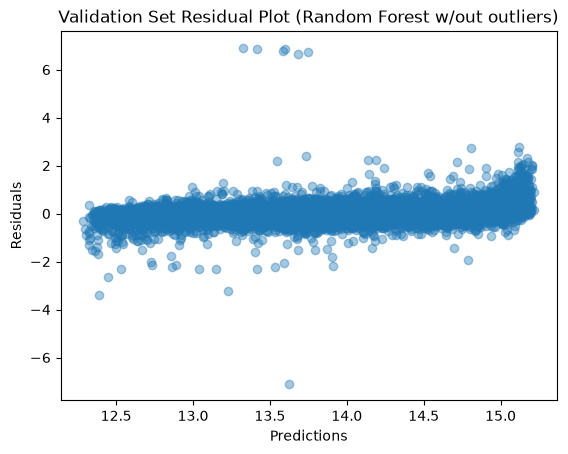

In [256]:
residuals_rf2 = np.log1p(Y_val) - pred_val_rf2

plt.scatter(pred_val_rf2, residuals_rf2, alpha=0.4)
plt.title('Validation Set Residual Plot (Random Forest w/out outliers)')
plt.xlabel('Predictions')
plt.ylabel('Residuals');

In [257]:
X_val[residuals_rf1 > 6]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
1583,33.022839,-116.804242,3.337237e+06,3.337237e+06,3.337237e+06,4.310591e+06,7.656810,3.0,2.0,1984.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5247,33.675959,-117.290553,6.086742e+05,6.460582e+05,6.565944e+05,6.654474e+05,7.633370,4.0,3.0,1997.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17017,32.625679,-117.065524,2.246132e+06,8.330027e+05,8.330027e+05,2.801790e+06,7.597396,4.0,3.0,1959.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26394,33.185572,-117.302394,9.903902e+05,9.348892e+05,9.366149e+05,9.389217e+05,7.007601,2.0,1.0,1972.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29606,32.572879,-117.062559,1.780421e+06,3.813746e+06,3.834100e+06,2.801790e+06,7.275865,4.0,2.0,1978.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30036,33.250628,-117.135871,1.034057e+06,1.035868e+06,1.034057e+06,1.021090e+06,7.568896,2.0,3.0,1977.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [258]:
X_val[residuals_rf2 > 6]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
1583,33.022839,-116.804242,3.337237e+06,3.337237e+06,3.337237e+06,4.310591e+06,7.656810,3.0,2.0,1984.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5247,33.675959,-117.290553,6.086742e+05,6.460582e+05,6.565944e+05,6.654474e+05,7.633370,4.0,3.0,1997.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17017,32.625679,-117.065524,2.246132e+06,8.330027e+05,8.330027e+05,2.801790e+06,7.597396,4.0,3.0,1959.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26394,33.185572,-117.302394,9.903902e+05,9.348892e+05,9.366149e+05,9.389217e+05,7.007601,2.0,1.0,1972.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29606,32.572879,-117.062559,1.780421e+06,3.813746e+06,3.834100e+06,2.801790e+06,7.275865,4.0,2.0,1978.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30036,33.250628,-117.135871,1.034057e+06,1.035868e+06,1.034057e+06,1.021090e+06,7.568896,2.0,3.0,1977.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [259]:
pd.DataFrame(Y_val).sort_values(0, ascending=False).head(6)

,0
30036,796000000.0
29606,768500000.0
1583,699000000.0
17017,664250000.0
26394,645000000.0
5247,615000000.0


In [260]:
X_val[residuals_rf1 < -6]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
28982,37.978534,-121.70934,699317.001873,706234.055416,1.337450e+06,1.551243e+06,8.000014,5.0,4.0,2026.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [261]:
X_val[residuals_rf2 < -6]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
28982,37.978534,-121.70934,699317.001873,706234.055416,1.337450e+06,1.551243e+06,8.000014,5.0,4.0,2026.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [262]:
pd.DataFrame(Y_val).sort_values(0).head(1)

,0
28982,685.0


The same is happening for our random forest, although the R2 score is higher.

### 2. Baseline Model Comparison

In [263]:
from sklearn.dummy import DummyRegressor

# always predict the median

# w/ outliers
dummy1 = DummyRegressor(strategy='median')
dummy1.fit(X_train, np.log1p(Y_train))
dummy_val_preds1 = dummy1.predict(X_val)

print("---Outliers included in training---")
print("Dummy baseline R²:", r2_score(np.log1p(Y_val), dummy_val_preds1))
print("Dummy baseline RMSE:", np.sqrt(mean_squared_error(np.log1p(Y_val), dummy_val_preds1)))
print("Dummy baseline MAE:", mean_absolute_error(np.log1p(Y_val), dummy_val_preds1))

print()

# w/out outliers
dummy2 = DummyRegressor(strategy='median')
dummy2.fit(X_train_no_outliers, np.log1p(Y_train_no_outliers))
dummy_val_preds2 = dummy2.predict(X_val)

print("---Outliers excluded in training---")
print("Dummy baseline R²:", r2_score(np.log1p(Y_val), dummy_val_preds2))
print("Dummy baseline RMSE:", np.sqrt(mean_squared_error(np.log1p(Y_val), dummy_val_preds2)))
print("Dummy baseline MAE:", mean_absolute_error(np.log1p(Y_val), dummy_val_preds2))

---Outliers included in training---
Dummy baseline R²: -0.018949186982569755
Dummy baseline RMSE: 0.6956118478502991
Dummy baseline MAE: 0.5242817180810135

---Outliers excluded in training---
Dummy baseline R²: -0.02273720453881123
Dummy baseline RMSE: 0.6969036421446497
Dummy baseline MAE: 0.5244771390034092


Our model still definitely performs better than a dummy model that predicts the median.

### 3. Model Behavior

Although our model performs with an R2 score of up to 0.86, it still consistently undervalues high properties.

**Final test set scores:**

In [264]:
# choose to include outliers in training

pred_test_dt = dt1.predict(X_test)

print("---Decision Tree---")
print("Decision Tree R²:", r2_score(np.log1p(Y_test), pred_test_dt))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(np.log1p(Y_test), pred_test_dt)))
print("Decision Tree MAE:", mean_absolute_error(np.log1p(Y_test), pred_test_dt))

print()

pred_test_rf = rf1.predict(X_test)

print("---Random Forest---")
print("Random Forest R²:", r2_score(np.log1p(Y_test), pred_test_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(np.log1p(Y_test), pred_test_rf)))
print("Random Forest MAE:", mean_absolute_error(np.log1p(Y_test), pred_test_rf))

---Decision Tree---
Decision Tree R²: 0.8525421626421762
Decision Tree RMSE: 0.26262321037145164
Decision Tree MAE: 0.1779983196330069

---Random Forest---
Random Forest R²: 0.8670971314797536


Random Forest RMSE: 0.24932530168008857
Random Forest MAE: 0.16508864429763934


Our results are largely similar, but we have different depths for each model. We should tune these hyperparameters later on.

Train/val/test splits (by number of months):
- (train/val/test - decision tree train R2/random forest train R2)
- 15/3/1 - 0.853/0.867
- 12/3/1 - 0.853/0.867
- 10/3/1 - 0.844/0.866
- 8/7/1 - 0.843/0.868
- 8/3/1 - 0.854/0.868 <-- best one, but not by much; could be randomness
- 7/3/1 - 0.849/0.867
- 5/3/1 - 0.821/0.860

The number of months in our validation set doesn't mean much yet, since we are basically treating it as another test set.